In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import torch
import numpy as np
import pandas as pd

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_project_path
)

from flonacomldft.internal_coordinates import (
    Coordinates_mapping
)

from flonacomldft.utils.diagnostics import R_hat

In [3]:
methods = ['adaptive', 'mixture_model']

In [4]:
simulation_types = dict(zip( methods, [
                    ['ab-flowMC', 'ab-flowMC w.o. MLP'],
                    ['ab-flowMM', 'ab-flowMM w.o. MLP']
                ])
            )

In [5]:
simulation_types

{'adaptive': ['ab-flowMC', 'ab-flowMC w.o. MLP'],
 'mixture_model': ['ab-flowMM', 'ab-flowMM w.o. MLP']}

In [6]:
simulation_idxs = { methods[0]: { simulation_types[methods[0]][0]: {
                        #0: 31959918,
                        #1: 319599111
                        #0: 31959917,
                        #1: 319599110,
                        #'0.3': {0: 31959916,
                        #1: 31959919,},
                        '1.0': {
                        #0: 32605970,
                        #1: 32605973,
                        0: 32606140,#32504326,
                        1: 32606143,#32510291,
                        },
                        'paper': {0: 30019620,
                        1: 30019624}
                    },

                    simulation_types[methods[0]][1]: {
                        '1.0': {0: 31961552,
                        1: 31961553},
                        'paper': {0: 29941690,
                        1: 29941694}
                    }
                },

                methods[1]: { 
                    simulation_types[methods[1]][0]: 
                        32094541,
                    simulation_types[methods[1]][1]:
                        32094594
                        
                }
            }

In [7]:
simulation_idxs

{'adaptive': {'ab-flowMC': {'1.0': {0: 32606140, 1: 32606143},
   'paper': {0: 30019620, 1: 30019624}},
  'ab-flowMC w.o. MLP': {'1.0': {0: 31961552, 1: 31961553},
   'paper': {0: 29941690, 1: 29941694}}},
 'mixture_model': {'ab-flowMM': 32094541, 'ab-flowMM w.o. MLP': 32094594}}

In [8]:
simulations_folders = {
    
    methods[0]: {
    simulation_types[methods[0]][0]: get_project_path() + "/2-adaptive-mlp",
    simulation_types[methods[0]][1]: get_project_path() + "/1-adaptive"
    },

    methods[1]: {
    simulation_types[methods[1]][0]: get_project_path() + "/5-multimodal-mlp",
    simulation_types[methods[1]][1]: get_project_path() + "/4-multimodal"
    }
}

save_path = get_project_path() + "/figures/preprint_v2/data"

In [9]:
simulations_folders

{'adaptive': {'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
  'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'},
 'mixture_model': {'ab-flowMM': '/mnt/home/amolina/ceph/adaptive-flow-mc/5-multimodal-mlp',
  'ab-flowMM w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/4-multimodal'}}

In [10]:
get_simulation_filename_adaptive = lambda isomer_label, idx: "results_adaptive_is{:d}_{:d}/adaptive_sampling_is{:d}_{:d}.pkl".format(
    isomer_label, idx, isomer_label, idx)
get_cvs_filename_adaptive = lambda isomer_label, idx: "results_adaptive_is{:d}_{:d}/cvs_is{:d}_{:d}.pkl".format(
    isomer_label, idx, isomer_label, idx)

In [11]:
get_simulation_filename_mm = lambda idx: "results_multimodal_sampling_mixture_{:d}/checkpoint_NA_3000.pkl".format(
    idx)
get_cvs_filename_mm = lambda idx: "cvs_temporal/cvs_slices_{:d}_3000.pkl".format(
    idx)

In [12]:
simulations_folders[methods[0]]

{'ab-flowMC': '/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp',
 'ab-flowMC w.o. MLP': '/mnt/home/amolina/ceph/adaptive-flow-mc/1-adaptive'}

# 1. Ab-flowMC simulations

In [13]:
method = methods[0]

adaptives = {}
cvss = {}

print("Loading data...")
for simulation in simulation_types[method]:
    adaptives[simulation] = {}
    cvss[simulation] = {}
    for frac, data in simulation_idxs[method][simulation].items():
        adaptives[simulation][frac] = {}
        cvss[simulation][frac] = {}
        for key, idx in data.items():
            adaptives[simulation][frac][key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
            simulations_folders[method][simulation])
            cvss[simulation][frac][key] = load_pickle_file(get_cvs_filename_adaptive(key, idx),
            simulations_folders[method][simulation])
            print("Loaded adaptive sampling {:s} and cvs for isomer {:d} and idx {:d}".format(
                simulation, key, idx))

Loading data...


Loaded adaptive sampling ab-flowMC and cvs for isomer 0 and idx 32606140
Loaded adaptive sampling ab-flowMC and cvs for isomer 1 and idx 32606143
Loaded adaptive sampling ab-flowMC and cvs for isomer 0 and idx 30019620
Loaded adaptive sampling ab-flowMC and cvs for isomer 1 and idx 30019624
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 0 and idx 31961552
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 1 and idx 31961553
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 0 and idx 29941690
Loaded adaptive sampling ab-flowMC w.o. MLP and cvs for isomer 1 and idx 29941694


In [14]:
#adaptive = adaptives[simulation_types[method][0]][0]
#adaptives[simulation_types[method][0]]

## 1.a Acceptance rate

In [15]:
accs_df = []

for simulation in simulation_types[method]:
    
    for frac, data in simulation_idxs[method][simulation].items():

        for key, idx in data.items():

            df = pd.DataFrame(columns=['Method', 'Isomer', 'Step', 'Acceptance Rate'])
            accs = torch.cat(adaptives[simulation][frac][key]['accs']).float().mean(dim=1).numpy()

            df['Acceptance Rate'] = accs
            df['Isomer'] = key
            df['Step'] = np.arange(0, len(accs))
            df['Method'] = simulation
            df['DFT frac'] = frac

            accs_df.append(df)

accs_df = pd.concat(accs_df)
#accs_df.to_csv(save_path + "/acceptance_rates.csv", index=False)
#print("Acceptance rates saved to {:s}".format(save_path + "/acceptance_rates.csv"))

In [16]:
from flonacomldft.utils.diagnostics import avg_windows    

In [17]:
accs_df_avg = []

for simulation in accs_df['Method'].unique():

    df = accs_df[accs_df['Method'] == simulation]
    
    for frac in df['DFT frac'].unique():

        for isomer in accs_df['Isomer'].unique():

            print(frac, isomer)
    
            df = accs_df[(accs_df['Method'] == simulation) &
                            (accs_df['Isomer'] == isomer) &
                            (accs_df['DFT frac'] == frac)]

            df_new = pd.DataFrame(columns=accs_df.columns)

            df_new['Acceptance Rate'] = avg_windows(
                df['Acceptance Rate'], 
                window_size=50, 
                axis=1)
            df_new['Step'] = avg_windows(
                df['Step'],
                window_size=50, 
                axis=1)
            df_new['Method'] = simulation
            df_new['Isomer'] = isomer
            df_new['DFT frac'] = frac
            accs_df_avg.append(df_new)
    
accs_df_avg = pd.concat(accs_df_avg)

1.0 0
1.0 1
paper 0
paper 1
1.0 0
1.0 1
paper 0
paper 1


In [18]:
accs_df_avg

,Method,Isomer,Step,Acceptance Rate,DFT frac
0,ab-flowMC,0,24.5,0.2940,1.0
1,ab-flowMC,0,25.5,0.2912,1.0
2,ab-flowMC,0,26.5,0.2900,1.0
3,ab-flowMC,0,27.5,0.2876,1.0
4,ab-flowMC,0,28.5,0.2888,1.0
...,...,...,...,...,...
546,ab-flowMC w.o. MLP,1,570.5,0.4928,paper
547,ab-flowMC w.o. MLP,1,571.5,0.4920,paper
548,ab-flowMC w.o. MLP,1,572.5,0.4920,paper
549,ab-flowMC w.o. MLP,1,573.5,0.4924,paper


In [19]:
accs_df

,Method,Isomer,Step,Acceptance Rate,DFT frac
0,ab-flowMC,0,0,0.42,1.0
1,ab-flowMC,0,1,0.34,1.0
2,ab-flowMC,0,2,0.38,1.0
3,ab-flowMC,0,3,0.24,1.0
4,ab-flowMC,0,4,0.26,1.0
...,...,...,...,...,...
595,ab-flowMC w.o. MLP,1,595,0.50,paper
596,ab-flowMC w.o. MLP,1,596,0.46,paper
597,ab-flowMC w.o. MLP,1,597,0.54,paper
598,ab-flowMC w.o. MLP,1,598,0.50,paper


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
colors = {'ab-flowMC': {'0.3': 'green', '1.0': 'blue', 'paper': 'black'},
          'ab-flowMC w.o. MLP': {'1.0': 'red', 'paper': 'purple'},}

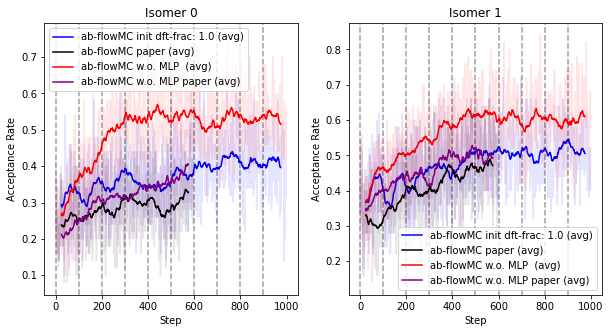

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for simulation in accs_df['Method'].unique():
        
    df = accs_df[accs_df['Method'] == simulation]
    df_avg = accs_df_avg[accs_df_avg['Method'] == simulation]
    
    for frac in df['DFT frac'].unique():

        for isomer in df['Isomer'].unique():
                
            if simulation == 'ab-flowMC' and frac == '1.0':
                 name = 'init dft-frac: ' + frac
            elif simulation == 'ab-flowMC' and frac != '1.0':
                name = frac
            elif simulation == 'ab-flowMC w.o. MLP' and frac == '1.0':
                name = ''
            else:
                name = frac
            
            df_new = df[(df['DFT frac'] == frac) & (df['Isomer'] == isomer)]
            df_new_avg = df_avg[(df_avg['DFT frac'] == frac) & (df_avg['Isomer'] == isomer)]
            
            sns.lineplot(x='Step', 
                            y='Acceptance Rate', 
                            data=df_new, 
                            ax=axs[isomer], 
                            #label="DFT frac {:s}".format(frac),
                            color=colors[simulation][frac],
                            alpha=0.1,
                            legend=False)
            
            sns.lineplot(x='Step',
                            y='Acceptance Rate',
                            data=df_new_avg,
                            ax=axs[isomer],
                            color=colors[simulation][frac],
                            label="{:s} {:s} (avg)".format(simulation, name))
            
            axs[isomer].set_title("Isomer {:d}".format(isomer))
            axs[isomer].set_xlabel("Step")
            axs[isomer].set_ylabel("Acceptance Rate")

            # plot vertical lines every 20 steps
            for i in range(0, 1000, 20*5):
                axs[isomer].axvline(i, color='black', linestyle='--', alpha=0.1)


## 1.b Collective variables and potential energy

In [23]:
adaptives['ab-flowMC w.o. MLP'].keys()

dict_keys(['1.0', 'paper'])

In [24]:
cvs_us_df = []

for simulation in adaptives.keys():

    for frac in adaptives[simulation].keys():

        print(frac)
        

        for isomer_label in [0, 1]:

            cvs = cvss[simulation][frac][isomer_label]
            print(cvs.shape)
            us = torch.cat(adaptives[simulation][frac][isomer_label]['us']).reshape(cvs.shape[0], cvs.shape[1], 1)


            cvs_us = torch.cat([us, cvs], dim=2).numpy().reshape(cvs.shape[0]*cvs.shape[1], 3)

            df = pd.DataFrame(cvs_us, columns=['U', 'C', 'R'])
            df['Isomer'] = isomer_label
            df['Method'] = simulation
            df['DFT frac'] = frac

            cvs_us_df.append(df)

cvs_us_df = pd.concat(cvs_us_df)
#cvs_us_df.to_csv(save_path + "/cvs_potential_energy.csv", index=False)
#print("CVs and potential energy saved to {:s}".format(save_path + "/cvs_potential_energy.csv"))
#cvs_us_df

1.0
torch.Size([1000, 50, 2])
torch.Size([1000, 50, 2])
paper
torch.Size([600, 50, 2])
torch.Size([600, 50, 2])
1.0
torch.Size([1000, 50, 2])
torch.Size([1000, 50, 2])
paper
torch.Size([600, 50, 2])
torch.Size([600, 50, 2])


## 1.c Rhat

In [25]:
rhat_df = []

for simulation in adaptives.keys():

    for frac in adaptives[simulation].keys():

        for isomer_label in [0, 1]:
            
            cvs = cvss[simulation][frac][isomer_label]
            us = torch.cat(adaptives[simulation][frac][isomer_label]['us']).reshape(cvs.shape[0], cvs.shape[1], 1)
            
            time_slices = adaptives[simulation][frac][isomer_label]['time_mcmc']
            print(simulation, isomer_label, frac, len(time_slices), cvs.shape[0])
            if len(time_slices) == cvs.shape[0]:
                time_mcmc = (np.array(time_slices)-min(time_slices) )/3600
            else:
                time_flatten = [t for time_slice in time_slices for t in time_slice]
                time_min = min(time_flatten)
                time_mcmc = np.array([t - time_min for t in time_flatten])/3600
    
            rhat_info = torch.cat((cvs, us), dim=2).detach().numpy()[:].transpose(1, 0, 2)
    
            rhat = R_hat(rhat_info, labels=['C', 'R', 'U'])
    
            df = pd.DataFrame(rhat[0], columns=['C', 'R', 'U'])
            df['Time (h)'] = time_mcmc[rhat[1]]
            df['MCMC step'] = rhat[1]
            df['Method'] = simulation
            df['Isomer'] = isomer_label
            df['DFT frac'] = frac
    
            rhat_df.append(df)

rhat_df = pd.concat(rhat_df)
#rhat_df.to_csv(save_path + "/rhat.csv", index=False)        
#rhat_df

ab-flowMC 0 1.0 50 1000


ab-flowMC 1 1.0 50 1000
ab-flowMC 0 paper 30 600
ab-flowMC 1 paper 30 600
ab-flowMC w.o. MLP 0 1.0 50 1000
ab-flowMC w.o. MLP 1 1.0 50 1000
ab-flowMC w.o. MLP 0 paper 600 600
ab-flowMC w.o. MLP 1 paper 600 600


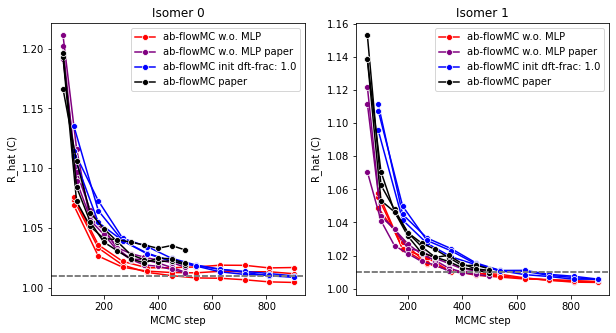

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for simulation in rhat_df['Method'].unique()[::-1]:
        
        df = rhat_df[rhat_df['Method'] == simulation]
        
        for frac in df['DFT frac'].unique():
    
            for isomer in df['Isomer'].unique():
                
                df_new = df[(df['DFT frac'] == frac) & (df['Isomer'] == isomer)]
                
                if simulation == 'ab-flowMC' and frac == '1.0':
                     name = 'init dft-frac: ' + frac
                elif simulation == 'ab-flowMC' and frac != '1.0':
                    name = frac
                elif simulation == 'ab-flowMC w.o. MLP' and frac == '1.0':
                    name = ''
                else:
                    name = frac
            

                for y_axis in ['C', 'R', 'U']:
                    
                    sns.lineplot(x='MCMC step',
                                y=y_axis,
                                data=df_new,
                                ax=axs[isomer],
                                marker='o',
                                color=colors[simulation][frac],
                                label="{:s} {:s}".format(simulation, name))
                
                #remove duplicated legend
                handles, labels = axs[isomer].get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                axs[isomer].legend(by_label.values(), by_label.keys())

                #do horizontal line at 1.01
                axs[isomer].axhline(y=1.01, color='gray', linestyle='--')

                axs[isomer].set_title("Isomer {:d}".format(isomer))
                axs[isomer].set_xlabel("MCMC step")
                axs[isomer].set_ylabel("R_hat (C)")


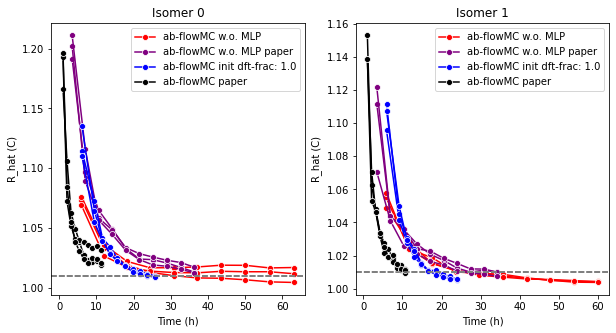

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for simulation in rhat_df['Method'].unique()[::-1]:
        
        df = rhat_df[rhat_df['Method'] == simulation]
        
        for frac in df['DFT frac'].unique():
    
            for isomer in df['Isomer'].unique():
                
                df_new = df[(df['DFT frac'] == frac) & (df['Isomer'] == isomer)]

                df_new = df[(df['DFT frac'] == frac) & (df['Isomer'] == isomer)]
                
                if simulation == 'ab-flowMC' and frac == '1.0':
                     name = 'init dft-frac: ' + frac
                elif simulation == 'ab-flowMC' and frac != '1.0':
                    name = frac
                elif simulation == 'ab-flowMC w.o. MLP' and frac == '1.0':
                    name = ''
                else:
                    name = frac
                
                for y_axis in ['C', 'R', 'U']:
                    
                    sns.lineplot(x='Time (h)',
                                y=y_axis,
                                data=df_new,
                                ax=axs[isomer],
                                marker='o',
                                color=colors[simulation][frac],
                                label="{:s} {:s}".format(simulation, name))
                
                #remove duplicated legend
                handles, labels = axs[isomer].get_legend_handles_labels()
                by_label = dict(zip(labels, handles))
                axs[isomer].legend(by_label.values(), by_label.keys())

                #do horizontal line at 1.01
                axs[isomer].axhline(y=1.01, color='gray', linestyle='--')

                axs[isomer].set_title("Isomer {:d}".format(isomer))
                axs[isomer].set_xlabel("Time (h)")
                axs[isomer].set_ylabel("R_hat (C)")

# Losses MLP

In [28]:
simulation_idxs['adaptive']['ab-flowMC']

{'1.0': {0: 32606140, 1: 32606143}, 'paper': {0: 30019620, 1: 30019624}}

In [29]:
idxs_old_new = simulation_idxs['adaptive']['ab-flowMC']#{'0.3': {0: 31959916,#30019620,
               #         1: 31959919#30019624
               #         },
               # '1.0': {0: 32504326,
               #         1: 32510291
               #         #0: 31959918,
               #         #1: 319599111
               #         }
               # }

In [30]:
adaptives_old_new = {}

for sim in idxs_old_new.keys():
    adaptives_old_new[sim] = {}
    for key, idx in idxs_old_new[sim].items():
        adaptives_old_new[sim][key] = load_pickle_file(get_simulation_filename_adaptive(key, idx), 
        simulations_folders['adaptive']['ab-flowMC'])
        print("Loaded adaptive sampling {:s} for isomer {:d} and idx {:d}".format(
            sim, key, idx))

Loaded adaptive sampling 1.0 for isomer 0 and idx 32606140
Loaded adaptive sampling 1.0 for isomer 1 and idx 32606143
Loaded adaptive sampling paper for isomer 0 and idx 30019620
Loaded adaptive sampling paper for isomer 1 and idx 30019624


Text(0.5, 0.98, 'Train and test losses All training MLPs')

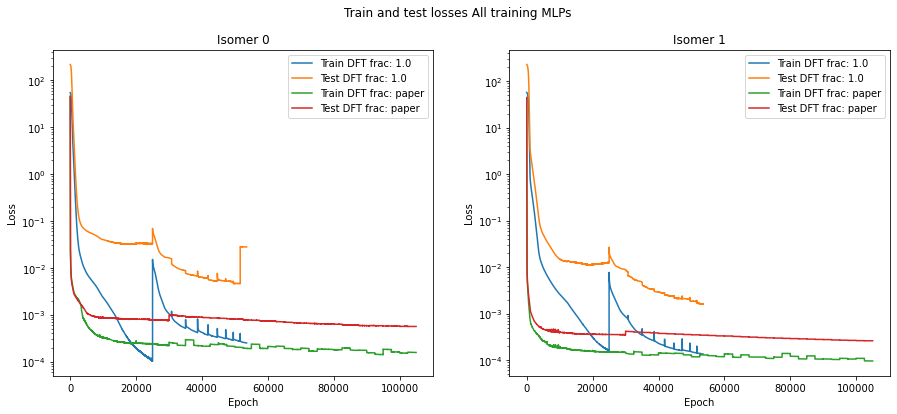

In [31]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

for sim in adaptives_old_new.keys():
    for key in adaptives_old_new[sim].keys():
        train_losses = []
        test_losses = []
        for training in adaptives_old_new[sim][key]['dict_mlps'][:]:
            if sim == 'paper':
                train_losses.append(training[0]['train_losses'])
                test_losses.append(training[0]['test_losses'])
            if sim == '1.0':
                train_losses.append(training[0]['avg_train_losses'])
                test_losses.append(training[0]['avg_test_losses'])
        train_losses_flat = [loss for sublist in train_losses for loss in sublist]
        test_losses_flat = [loss for sublist in test_losses for loss in sublist]
        
        axs[key].plot(train_losses_flat, label='Train DFT frac: {:s}'.format(sim))
        axs[key].plot(test_losses_flat, label='Test DFT frac: {:s}'.format(sim))

        axs[key].set_title('Isomer {:d}'.format(key))
        axs[key].set_xlabel('Epoch')
        axs[key].set_ylabel('Loss')
        axs[key].legend()

        axs[key].set_yscale('log')

fig.suptitle('Train and test losses All training MLPs')

Text(0.5, 0.98, 'Train and test losses Adaptive training MLPs')

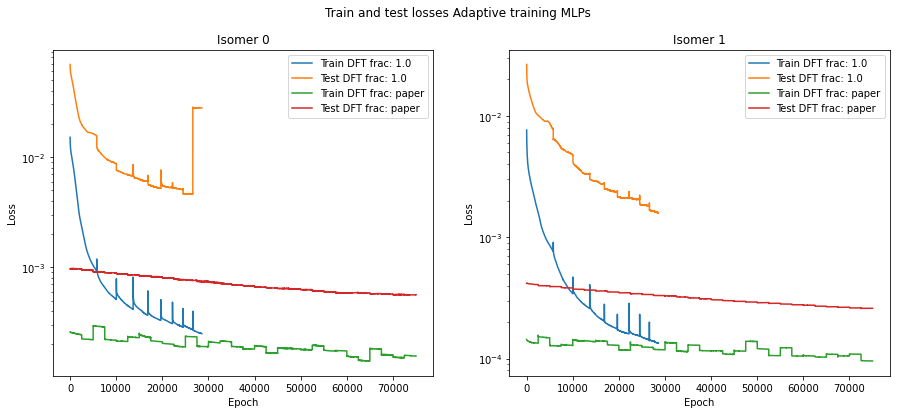

In [32]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

for sim in adaptives_old_new.keys():
    for key in adaptives_old_new[sim].keys():
        train_losses = []
        test_losses = []
        for training in adaptives_old_new[sim][key]['dict_mlps'][1:]:
            if sim == 'paper':
                train_losses.append(training[0]['train_losses'])
                test_losses.append(training[0]['test_losses'])
            if sim == '1.0':
                train_losses.append(training[0]['avg_train_losses'])
                test_losses.append(training[0]['avg_test_losses'])
        train_losses_flat = [loss for sublist in train_losses for loss in sublist]
        test_losses_flat = [loss for sublist in test_losses for loss in sublist]
        
        axs[key].plot(train_losses_flat, label='Train DFT frac: {:s}'.format(sim))
        axs[key].plot(test_losses_flat, label='Test DFT frac: {:s}'.format(sim))

        axs[key].set_title('Isomer {:d}'.format(key))
        axs[key].set_xlabel('Epoch')
        axs[key].set_ylabel('Loss')
        axs[key].legend()

        axs[key].set_yscale('log')

fig.suptitle('Train and test losses Adaptive training MLPs')